# RNNs. Sequence classification
# Agenda

1. [RNN Theory](#rnn)
2. [Gradients and Backpropagation Through Time](#bptt)
3. [Text classification](#classification)
4. [Tokenization](#tokenization)
5. [Embeddings](#embeddings)
6. [RNNs examples](#practice)

<a id='rnn'></a>
# RNN Theory


## Nature of sequential data

**Sequential data** has an inherent order: $(x_1, x_2, \dots, x_T)$. The meaning of $x_t$ depends on the context $(x_1,\dots, x_{t-1})$.  
Classical tabular/MLP setups assume i.i.d. samples with a fixed-size feature vector, losing temporal order unless we manually encode it.

**Limitations of tabular approaches:**
- Fixed-length windows; long-range dependencies beyond the window are lost.
- Parameters tied to positions (no temporal weight sharing).
- No built-in memory/state that persists across time.

**RNN motivation:** process inputs sequentially and carry a state that summarizes history.


## RNN architecture

<img src="https://cdn-images-1.medium.com/max/1600/1*NKhwsOYNUT5xU7Pyf6Znhg.png">

Given input $x_t \in \mathbb{R}^{d_x}$ and hidden state $h_{t-1} \in \mathbb{R}^{d_h}$, a **vanilla RNN** updates:
$$
h_t = \phi(W_{xh} x_t + W_{hh} h_{t-1} + b_h), \quad \phi=\tanh \text{ (commonly)}
$$

**Weight sharing across time** makes the unrolled computation a deep network of depth $T$ with tied parameters.


<a id='bptt'></a>
# Gradients and Backpropagation Through Time

## Forward (classify with the last hidden)

For $t=1,\dots,T$:
$$
\begin{aligned}
a_t &= W_{hh}h_{t-1} + W_{xh}x_t + b_h,\\\\
h_t &= \tanh(a_t).
\end{aligned}
$$

Readout only at the last step:
$$
o_T = W_{hy}h_T + b_y,\qquad
\hat y = \mathrm{softmax}(o_T),\qquad
L = \mathrm{CE}(\hat y,\; y).
$$

During forward, **cache** $a_t, h_t$ for all $t$. The superscript ${\mathbf T}$ denotes **transpose**; it is used to form outer products such as $\left(\partial L/\partial o_T\right) h_T^{\mathbf T}$.


## Backward: from $T$ down to $1$

Unroll the RNN across time and imagine **separate copies** of the shared parameters:
$W_{xh}^{(1)},, W_{xh}^{(2)},, \dots,, W_{xh}^{(T)}$ (and similarly for $W_{hh},, b_h$).

The total loss is $L$ (only the final head contributes, but the forward dynamics use all steps).

The gradient with respect to the **tied** parameter $W_{xh}$ equals the **sum** of the gradients with respect to each time-slice copy, evaluated at the same value:
$$ \frac{\partial L}{\partial W_{xh}} = \sum_{t=1}^{T}
\frac{\partial L}{\partial W_{xh}^{(t)}}
$$

The same holds for $W_{hh}$ and $b_h$. This is a direct consequence of the **chain rule with parameter sharing**: the loss depends on **each time-slice usage** of the same matrix; therefore, the total sensitivity is the **sum** of sensitivities from each usage.


Initialize the “future” carry:
$$
\frac{\partial L}{\partial h_{T+1}} := 0.
$$

### Step A (only at $T$): output head

For softmax + cross-entropy:
$$
\boxed{\frac{\partial L}{\partial o_T} = \hat y - y.}
$$

Accumulate readout parameters:
$$
\boxed{
\frac{\partial L}{\partial W_{hy}} = \left(\frac{\partial L}{\partial o_T}\right) h_T^{\mathbf T},
\qquad
\frac{\partial L}{\partial b_y} = \frac{\partial L}{\partial o_T}.
}
$$

### Step B (at $T$): into $h_T$, then to $a_T$

Only the $T$-head contributes here (earlier steps have no head):
$$
\boxed{
\frac{\partial L}{\partial h_T}
=
W_{hy}^{\mathbf T}\left(\frac{\partial L}{\partial o_T}\right)
\;+\; \underbrace{\frac{\partial L}{\partial h_{T+1}}}_{0}
}
$$

With $\tanh$, the elementwise derivative is $\tanh'(a) = 1 - \tanh^2(a)$. Therefore,
$$
\boxed{
\frac{\partial L}{\partial a_T}
=
\left(\frac{\partial L}{\partial h_T}\right)\odot \big(1-\tanh^2(a_T)\big).
}
$$

### Step C (core params at $T$) and pass to $t=T-1$

$$
\boxed{
\begin{aligned}
\frac{\partial L}{\partial W_{xh}} &\mathrel{+}= \left(\frac{\partial L}{\partial a_T}\right) x_T^{\mathbf T},\\\\
\frac{\partial L}{\partial W_{hh}} &\mathrel{+}= \left(\frac{\partial L}{\partial a_T}\right) h_{T-1}^{\mathbf T},\\\\
\frac{\partial L}{\partial b_h}    &\mathrel{+}= \frac{\partial L}{\partial a_T}.
\end{aligned}}
$$

Pass to previous hidden:
$$
\boxed{
\frac{\partial L}{\partial h_{T-1}} = W_{hh}^{\mathbf T}\left(\frac{\partial L}{\partial a_T}\right).
}
$$

### Steps for $t=T-1,\,T-2,\,\dots,\,1$

Then
$$
\boxed{
\frac{\partial L}{\partial a_t}
=
\left(\frac{\partial L}{\partial h_t}\right)\odot \big(1-\tanh^2(a_t)\big),
}
$$

accumulate parameters,
$$
\boxed{
\begin{aligned}
\frac{\partial L}{\partial W_{xh}} &\mathrel{+}= \left(\frac{\partial L}{\partial a_t}\right) x_t^{\mathbf T},\\\\
\frac{\partial L}{\partial W_{hh}} &\mathrel{+}= \left(\frac{\partial L}{\partial a_t}\right) h_{t-1}^{\mathbf T},\\\\
\frac{\partial L}{\partial b_h}    &\mathrel{+}= \frac{\partial L}{\partial a_t},
\end{aligned}}
$$

and pass further back:
$$
\boxed{
\frac{\partial L}{\partial h_{t-1}} = W_{hh}^{\mathbf T}\left(\frac{\partial L}{\partial a_t}\right).
}
$$

Stop at $t=1$. (If you use $h_0=0$ or a learned $h_0$, handle it accordingly.)



## Vanishing/exploding gradients with **tanh**

The vanishing gradient problem is a difficulty in training artificial neural networks with gradient-based learning methods and backpropagation. In such methods, each of the neural network's weights receives an update proportional to the partial derivative of the error function with respect to the current weight in each training iteration. The problem is that, in some cases, the gradient will be vanishingly small, effectively preventing the weight from changing its value. In the worst case, this may completely stop the neural network from further training. As one example of the problem cause, traditional activation functions such as the hyperbolic tangent function have gradients in the range (0, 1), and backpropagation computes gradients by the chain rule. This fact has the effect of multiplying n of these small numbers to compute gradients of the "front" layers in an n-layer network, meaning that the gradient (error signal) decreases exponentially with n, resulting in the slow training of the front layers.

<img src="https://cdn-images-1.medium.com/max/1460/1*FWy4STsp8k0M5Yd8LifG_Q.png">

Source: [Medium](https://medium.com/@anishsingh20/the-vanishing-gradient-problem-48ae7f501257).

Each step’s hidden depends on the previous hidden:
$$
h_j=\tanh(a_j),\qquad a_j=W_{hh}h_{j-1}+W_{xh}x_j+b_h.
$$

The Jacobian of $h_j$ w.r.t. $h_{j-1}$ is
$$
\frac{\partial h_j}{\partial h_{j-1}}
=
\underbrace{\operatorname{Diag}\!\big(1-\tanh^2(a_j)\big)}_{\in [0,1]}\; W_{hh}.
$$

To connect an early state $h_k$ to a later one $h_t$ ($t>k$), the **chain rule multiplies** Jacobians across all intermediate steps:
$$
\boxed{
\frac{\partial h_t}{\partial h_k}
=
\prod_{j=k+1}^{t}
\Big[\operatorname{Diag}\!\big(1-\tanh^2(a_j)\big)\, W_{hh}\Big].
}
$$

Taking norms (any submultiplicative norm):
$$
\boxed{
\left\|\frac{\partial h_t}{\partial h_k}\right\|
\;\le\;
\prod_{j=k+1}^{t}
\Big\|\,\operatorname{Diag}\!\big(1-\tanh^2(a_j)\big)\Big\|
\cdot \|W_{hh}\|.
}
$$

- Since $0 \le 1-\tanh^2(\cdot) \le 1$ and is **typically < 1** away from zero, if the **typical factor**
  $\|W_{hh}\|\cdot \mathbb E[\,1-\tanh^2(a_j)\,] < 1$, the product **shrinks exponentially** with $(t-k)$ $\to$ **vanishing**.
- e.g. $0.8^{20} \approx 0.01$ so it's almost-zero effect on context dependencies with length >> 10
- If it’s $>1$, the product can **grow exponentially** $\to$ **exploding** so using something like ReLU is also questionable.


## Toy example: Scalar RNN

Let
$$
h_t=\tanh(\alpha\, h_{t-1} + \beta\, x_t).
$$

Linearize locally so $\tanh'(a)\approx c$ with $c\in(0,1]$. Then
$$
\boxed{
\frac{\partial h_t}{\partial h_k}\;\approx\; (\alpha\, c)^{\,t-k}.
}
$$

- If $|\alpha c|<1 \Rightarrow$ vanishing (decays geometrically).
- If $|\alpha c|>1 \Rightarrow$ exploding (grows geometrically).

Because $\tanh'\le 1$ and often $<1$, you usually need $W_{hh}$ carefully initialized (e.g., orthogonal/identity-scaled), **gradient clipping**, and sometimes **truncated BPTT** to avoid these extremes.


## Global Average/Max Pooling over RNN Hidden States: Why it Can Help with Vanishing Gradients

### Global Average Pooling
Define
$$
p \;=\; \frac{1}{T}\sum_{t=1}^T h_t.
$$
Then
$$
\frac{\partial L}{\partial h_t}
\;=\;
\frac{1}{T}\,W_{hy}^\top \frac{\partial L}{\partial o},
\qquad
\frac{\partial L}{\partial a_t}
\;=\;
\Big(\frac{1}{T}\,W_{hy}^\top \frac{\partial L}{\partial o}\Big)\odot \phi'(a_t),
$$
so each time step $t$ receives a **direct** gradient from the loss, without passing through a long chain of recurrent Jacobians.

Parameter updates at each time $t$ become
$$
\frac{\partial L}{\partial W_{xh}} \mathrel{+}= \Big(\frac{\partial L}{\partial a_t}\Big) x_t^\top,\qquad
\frac{\partial L}{\partial W_{hh}} \mathrel{+}= \Big(\frac{\partial L}{\partial a_t}\Big) h_{t-1}^\top,\qquad
\frac{\partial L}{\partial b_h} \mathrel{+}= \frac{\partial L}{\partial a_t}.
$$

**Why this helps:** the gradient path from $L$ to $h_t$ is **short** (one affine map $W_{hy}$), so it **avoids** the product of many recurrent Jacobians that causes vanishing when supervising only the last hidden state.

**Limitation:** the signal is scaled by $1/T$ and $p$ is **order-agnostic**.

### Global Max Pooling (elementwise)
Define, per feature $j$,
$$
p[j] \;=\; \max_{1\le t\le T} h_t[j].
$$
Let $m_t[j]=\mathbf{1}\{\,t=\arg\max_{\tau} h_\tau[j]\,\}$ be the winner mask (ties handled arbitrarily). Then
$$
\frac{\partial L}{\partial h_t[j]}
\;=\;
m_t[j]\;\Big(W_{hy}^\top \frac{\partial L}{\partial o}\Big)[j],
\qquad
\frac{\partial L}{\partial a_t}
\;=\;
\Big(\frac{\partial L}{\partial h_t}\Big)\odot \phi'(a_t).
$$
Only the **winning** time step for each feature receives gradient on that feature, again via a **short** path that bypasses deep temporal products.

**Why this helps:** like average pooling, it short-circuits long chains and can focus learning on salient spikes.

**Limitation:** gradients are **sparse** across time/features and still **order-agnostic**.



## Overall thoughts

**RNNs Applications:** legacy NLP (tagging, classification, NER), time series forecasting, sequential tabular, healthcare, temporal aggregation.

**Pros of RNNs:**
- Linear-time in sequence length; streamable; fixed parameters reused over time.
- Good in small-data or resource-constrained setups; strong sequential inductive bias.

**Cons of RNNs:**
- Vanishing/exploding gradients; limited long-range memory (without gating).
- Limited parallelism across time;
- Transformers typically excel at long-range dependencies and parallel training.

**Takeaway:** RNNs remain relevant for memory-wise sequence processing, small models, or constrained settings.

<a id='classification'></a>
# 3. Text classification

Let's take a look at NLP example [Disaster Tweets](https://www.kaggle.com/competitions/nlp-getting-started):
![](https://storage.googleapis.com/kaggle-media/competitions/tweet_screenshot.png)

The author explicitly uses the word “ABLAZE” (палаючий) but means it metaphorically. This is clear to a human right away, especially with the visual aid. But it’s less clear to a machine.

In this competition, you’re challenged to build a machine learning model that predicts which Tweets are about real disasters and which one’s aren’t. You’ll have access to a dataset of 10,000 tweets that were hand classified.
Disclaimer: The dataset for this competition contains text that may be considered profane, vulgar, or offensive.

**Please check info about Kaggle API** [here](https://www.google.com/url?sa=t&rct=j&q=&esrc=s&source=web&cd=&cad=rja&uact=8&ved=2ahUKEwifhoe5_7mBAxXPGRAIHXuXAWIQFnoECBIQAw&url=https%3A%2F%2Fgithub.com%2FKaggle%2Fkaggle-api%23%3A~%3Atext%3DTo%2520use%2520the%2520Kaggle%2520API%2Cfile%2520containing%2520your%2520API%2520credentials.&usg=AOvVaw1BewOUEPrUy1mWsrqk8T5U&opi=89978449)

In [1]:
import platform

!kaggle competitions download -c nlp-getting-started

# Check if using Windows or Unix-based system
if platform.system() == "Windows":
    !powershell -command Expand-Archive nlp-getting-started.zip -DestinationPath nlp-getting-started -Force
else:
    !unzip nlp-getting-started.zip -d nlp-getting-started

nlp-getting-started.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  nlp-getting-started.zip
replace nlp-getting-started/sample_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: ^C


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

df_twitter = pd.read_csv('nlp-getting-started/train.csv')
df_twitter.sample(5)

,id,keyword,location,text,target
255,363,annihilation,United States,Are souls punished withåÊannihilation? http://...,0
2000,2875,damage,Unknown,@BradleyBrad47 the saw is fast af and does gre...,0
6540,9355,survived,?,@TheSmallClark 'He'll kill me instead if he su...,1
3056,4384,earthquake,NaN,#USGS M 1.4 - 4km E of Interlaken California: ...,0
5813,8296,rubble,NaN,@accionempresa ChinaÛªs stock market crash th...,1


In [2]:
#straightforward train/test split

X_train, X_test, y_train, y_test = train_test_split(
    df_twitter.text, df_twitter.target, test_size=0.2, random_state=42, shuffle=True, stratify=df_twitter.target
)

<a id='tokenization'></a>
# Tokenization

## Preliminaries: What is a tokenizer?

A tokenizer is a function that maps a text string to a sequence of discrete symbols (tokens):
$$
T:\ \text{text}\ \mapsto\ (t_1,\dots,t_n), \quad t_i \in \mathcal{V},
$$
where $\mathcal{V}$ is the **vocabulary**. A detokenizer (or decoder) maps back to text (possibly with loss).

The choice of $T$ and $\mathcal{V}$ trades off:
- Vocabulary size $|\mathcal{V}|$
- Average sequence length $n$ (after tokenization)
- Coverage (open vs. closed vocab), OOV handling
- Robustness to morphology, spelling variation, and multilingual scripts
- Compression / modeling efficiency


## Word-level tokenization

### Definition
Split text into **word types** (e.g., by whitespace and punctuation rules) and map each unique word to a token ID. Let $\Sigma_{\text{word}}$ be the set of word types seen during training; then
$$
\mathcal{V} = \Sigma_{\text{word}} \cup \{\text{[UNK]},\text{[PAD]},\dots\}.
$$

### Vocabulary construction
1. **Normalize** (lowercasing, Unicode NFKC, strip punctuation or keep — design choice).
2. **Scan corpus**; count word types $w$ and sort by frequency.
3. **Select top-$K$** to form $\mathcal{V}$ and map the rest to **[UNK]**.

Formally, with corpus $C$:
$$
\mathcal{V}_K = \underset{S \subseteq \Sigma_{\text{word}},\ |S|=K}{\arg\max}\ \sum_{w \in S} \text{count}_C(w).
$$

### Forward model footprint
- Embedding table of shape $|\mathcal{V}|\times d$.
- Softmax head of shape $d\times |\mathcal{V}|$ (for LM).

### Pros
- Simple and fast.
- Human-interpretable tokens.

### Cons
- Closed vocab: OOV words $\to$ [UNK].
- Morphology/inflection explodes $|\mathcal{V}|$ (e.g., agglutinative languages).
- Misses shared substructure across words (no subword sharing).
- Memory + compute grow with $|\mathcal{V}|$.


## 2) Subword Tokenization via BPE (Byte‑Pair Encoding)

### Intuition
Represent words by a sequence of **subword units** learned from data. Start from characters; **merge** the most frequent adjacent pairs to form longer units, iteratively.

### Vocabulary construction (frequency-based merges)
- Initialize with characters (or bytes) plus an end‑of‑word marker `</w>`:
  $$
  \mathcal{V}_0 = \Sigma_{\text{char}} \cup \{\texttt{</w>}\}.
  $$
- Consider each word as a sequence of initial tokens ending with `</w>`.
- Repeat for $M$ merges:
  1. Count adjacent token pairs over the whole corpus:
$$f(u,v) = \text{occurrences of bigram }(u,v).$$
  2. Pick the **most frequent** pair $(u^*,v^*) = \arg\max_{u,v} f(u,v)$.
  3. **Merge** it into a new symbol $w = u^* \!\oplus v^*$ and update all sequences.
- Final vocabulary:
  $$
  \mathcal{V} = \mathcal{V}_0 \cup \{w_1,\dots,w_M\}, \quad |\mathcal{V}| = |\Sigma_{\text{char}}| + 1 + M.
  $$

### Tokenization (apply learned merges)
Given a word, apply merges **greedily** in the learned rank order to produce the subword sequence; concatenate across words.

### Why this helps (math lens)
BPE approximates a compression objective: each merge increases the corpus likelihood under an implicit $n$‑gram or reduces description length by reusing frequent substrings. While we do not fit probabilities explicitly, merging the most frequent pairs maximizes count mass captured by subwords.

### Pros
- **Open vocabulary** (character fallback) — no [UNK] for unseen words.
- Shares statistics between related words (morphology, compounds).
- Controls $|\mathcal{V}|$ via number of merges $M$.
- Deterministic and efficient.

### Cons 
- Merge criterion is **pure frequency**, not a true likelihood; subwords may ignore morpheme boundaries.
- Sensitive to normalization (casing, whitespace markers).

In [3]:
import re
from collections import Counter

PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
PAD_ID = 0
UNK_ID = 1
WORD_VOCAB_MAX = 20_000  # cap

def word_tokenize(text: str):
    # Lowercasing and basic tokenization: split on non-word characters
    text = text.lower()
    toks = re.findall(r"[a-z0-9_]+", text)
    return toks

word_counts = Counter()
for t in df_twitter.text.tolist():
    word_counts.update(word_tokenize(t))

print(f'Total unique words: {len(word_counts)}')

# Build vocab: [<pad>, <unk>] + most common words
most_common = [w for w,_ in word_counts.most_common(WORD_VOCAB_MAX - 2)]
word_vocab = [PAD_TOKEN, UNK_TOKEN] + most_common
word2id = {w:i for i,w in enumerate(word_vocab)}
id2word = {i:w for w,i in word2id.items()}

def encode_words(text: str):
    toks = word_tokenize(text)
    return [word2id.get(tok, UNK_ID) for tok in toks]

vocab_size_word = len(word2id)
vocab_size_word

Total unique words: 21571


20000

In [4]:
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, processors

# Prepare iterator over training texts
def text_iterator(series, batch_size=1000):
    batch = []
    for text in series:
        batch.append(text.lower())
        if len(batch) >= batch_size:
            yield batch
            batch = []
    if batch:
        yield batch

BPE_VOCAB_SIZE = 1_000
bpe_tokenizer = Tokenizer(models.BPE(unk_token=UNK_TOKEN))
bpe_tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()
trainer = trainers.BpeTrainer(vocab_size=BPE_VOCAB_SIZE, special_tokens=[PAD_TOKEN, UNK_TOKEN])
bpe_tokenizer.train_from_iterator(text_iterator(df_twitter["text"]), trainer=trainer)

# Make PAD_ID=0 across both tokenizers for convenience by remapping if necessary
# (tokenizers library stores vocab as token->id dict; we will just keep PAD as a special pad token externally)
bpe_vocab = bpe_tokenizer.get_vocab()
len(bpe_vocab)

1000

In [5]:
# Helper wrappers for BPE encode/decode to IDs with PAD=0 fallback
# We'll store PAD as 0 and UNK as the tokenizer's unk id for consistency.
BPE_PAD_ID = 0
BPE_UNK_ID = bpe_tokenizer.token_to_id(UNK_TOKEN)

def encode_bpe(text: str):
    ids = bpe_tokenizer.encode(text.lower()).ids
    # Keep original ids; padding will use 0 in collator
    return ids

# Quick smoke test
print(bpe_tokenizer.encode("fire at the refinery").tokens)
print(encode_bpe("fire at the refinery")[:10])


['fire', 'at', 'the', 're', 'fin', 'er', 'y']
[239, 108, 111, 100, 751, 97, 62]


17.056088270064365


<Axes: >

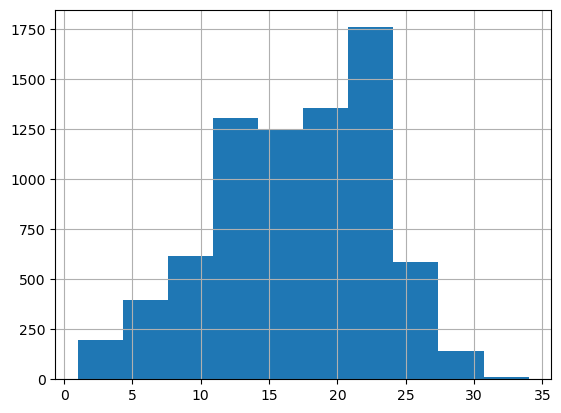

In [6]:
print(df_twitter.text.apply(word_tokenize).apply(len).mean())
df_twitter.text.apply(word_tokenize).apply(len).hist()

40.45238407986339


<Axes: >

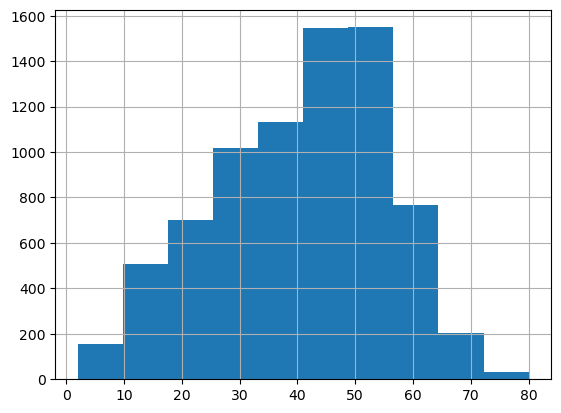

In [7]:
print(df_twitter.text.apply(encode_bpe).apply(len).mean())
df_twitter.text.apply(encode_bpe).apply(len).hist()

In [8]:
import torch
from torch.utils.data import Dataset

class SeqDataset(Dataset):
    def __init__(self, texts, labels, encoder: str):
        self.texts = list(texts)
        self.labels = list(labels)
        self.encoder = encoder  # 'word' or 'bpe'
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        t = self.texts[idx]
        y = int(self.labels[idx])
        if self.encoder == "word":
            ids = encode_words(str(t).lower().strip())
        else:
            ids = encode_bpe(str(t).lower().strip())
        return torch.tensor(ids, dtype=torch.long), torch.tensor(y, dtype=torch.long)

train_word_ds = SeqDataset(X_train.tolist(), y_train, "word")
val_word_ds   = SeqDataset(X_test.tolist(),   y_test,   "word")
train_bpe_ds  = SeqDataset(X_train.tolist(), y_train, "bpe")
val_bpe_ds    = SeqDataset(X_test.tolist(),   y_test,   "bpe")
len(train_word_ds), len(train_bpe_ds), len(val_word_ds), len(val_bpe_ds)

(6090, 6090, 1523, 1523)

In [9]:
from torch.nn.utils.rnn import pad_sequence

def make_collate_fn(pad_id: int):
    def collate(batch):
        seqs, labels = zip(*batch)
        lengths = torch.tensor([len(s) for s in seqs], dtype=torch.long)
        padded = pad_sequence(seqs, batch_first=True, padding_value=pad_id)
        return {"input_ids": padded, "lengths": lengths, "labels": torch.tensor(labels, dtype=torch.long)}
    return collate

word_collate = make_collate_fn(PAD_ID)      # 0
bpe_collate  = make_collate_fn(BPE_PAD_ID)  # 0

<a id='embeddings'></a>
# Embeddings

## What is an embedding layer and how does it work?

### Definition and Shapes
An embedding layer is a **learned lookup table** that maps token IDs to dense vectors.
- Vocabulary $\mathcal{V}$ with size $|\mathcal{V}|$.
- Embedding dimension $d$.
- Parameters: the **embedding matrix** $E \in \mathbb{R}^{|\mathcal{V}| \times d}$. Row $E[i,:]$ is the vector for token ID $i$.

Given a tokenized sequence $(t_1,\dots,t_n)$ with $t_k \in \{0,\dots,|\mathcal{V}|-1\}$, the embedding layer outputs
$$
\big(e_1,\dots,e_n\big), \quad e_k \in \mathbb{R}^d, \quad e_k = E[t_k,:].
$$

### One‑hot view (for intuition)
Let $x_k \in \{0,1\}^{|\mathcal{V}|}$ be a one‑hot vector for token $t_k$. Then
$$
e_k \;=\; E^\top x_k \;\;\in\;\mathbb{R}^d.
$$
This makes it clear the operation is **linear selection** of a row of $E$.

![](https://miro.medium.com/v2/resize:fit:4800/format:webp/1*NuWIU2Iew3Bm8NR78tRj8A.png)

### Backpropagation (how rows get gradients)
Suppose the downstream loss is $L$. The gradient in the embedding matrix accumulates only on the **rows that were looked up**:
$$
\frac{\partial L}{\partial E[i,:]} \;=\; \sum_{k:\, t_k = i} \frac{\partial L}{\partial e_k} \;\;\in\;\mathbb{R}^d.
$$
All other rows receive zero gradient for that batch.

### Where embeddings sit in the model
Embeddings usually feed into a sequence model (RNN/Transformer/CNN). A **positional encoding** (absolute or relative) is often added, especially for Transformers:
$$
z_k \;=\; e_k \;+\; p_k, \qquad p_k \in \mathbb{R}^d.
$$


<a id='practice'></a>
# RNNs examples

Multi-layer RNN<br>
![](https://d2l.ai/_images/deep-rnn.svg)

In [10]:
import torch.nn as nn

class VanillaRNNClassifier(nn.Module):
    def __init__(
        self, vocab_size: int, 
        num_rnn_layers=3,
        embed_dim: int = 256, hidden_dim: int = 256, 
        num_classes: int = 2, pad_id: int = 0
    ):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.rnn   = nn.RNN(
            input_size=embed_dim, hidden_size=hidden_dim, 
            nonlinearity="tanh", batch_first=True, num_layers=num_rnn_layers
        )
        self.fc    = nn.Linear(hidden_dim, num_classes)

    def forward(self, input_ids=None, lengths=None, labels=None, **kwargs):
        # input_ids: [B, T]
        emb = self.embed(input_ids)  # [B, T, E]
        # Pack to skip pads in RNN compute
        packed = nn.utils.rnn.pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        out_packed, h_n = self.rnn(packed)   # h_n: [1, B, H]
        last_h = h_n[-1]                     # [B, H]
        logits = self.fc(last_h)             # [B, C]
        loss = None
        if labels is not None:
            loss_fn = nn.CrossEntropyLoss()
            loss = loss_fn(logits, labels)
        return {"loss": loss, "logits": logits}

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [11]:
vocab_size_word, vocab_size_bpe = len(word2id), len(bpe_vocab)
print("Word vocab:", vocab_size_word, "| BPE vocab:", len(bpe_vocab))
print("Example param counts:")
print("Word-RNN:", count_params(VanillaRNNClassifier(vocab_size_word)))
print("BPE-RNN :", count_params(VanillaRNNClassifier(len(bpe_vocab))))

Word vocab: 20000 | BPE vocab: 1000
Example param counts:
Word-RNN: 5515266
BPE-RNN : 651266


In [12]:
import os
from transformers import Trainer, TrainingArguments
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

os.environ.setdefault("WANDB_DISABLED", "true")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits[:, 1]
    auc = roc_auc_score(labels, preds)
    return {"auc": auc}

In [13]:
from torch.utils.data import DataLoader

BATCH_TRAIN = 64
BATCH_EVAL  = 64
EPOCHS = 10
LR = 2e-4

# Word-level
word_model = VanillaRNNClassifier(vocab_size=vocab_size_word, pad_id=PAD_ID)

word_args = TrainingArguments(
    output_dir="out_word_rnn",
    per_device_train_batch_size=BATCH_TRAIN,
    per_device_eval_batch_size=BATCH_EVAL,
    num_train_epochs=EPOCHS,
    learning_rate=LR,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="auc",
    greater_is_better=True,
    seed=42,
)

trainer_word = Trainer(
    model=word_model,
    args=word_args,
    train_dataset=train_word_ds,
    eval_dataset=val_word_ds,
    data_collator=word_collate,
    compute_metrics=compute_metrics,
)
print("Word-level model params:", count_params(word_model))

trainer_word.train()
word_metrics = trainer_word.evaluate()
word_metrics

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Word-level model params: 5515266


Epoch,Training Loss,Validation Loss,Auc
1,0.660400,0.645413,0.699739
2,0.573100,0.576084,0.763856
3,0.472400,0.581805,0.772361
4,0.422100,0.581312,0.778720
5,0.371300,0.612608,0.780800
6,0.335400,0.659238,0.774179
7,0.279100,0.691312,0.776570
8,0.252900,0.736620,0.777313
9,0.228900,0.761266,0.775087
10,0.206500,0.775521,0.774137


{'eval_loss': 0.6126083731651306,
 'eval_auc': 0.780800104165567,
 'eval_runtime': 0.1574,
 'eval_samples_per_second': 9677.208,
 'eval_steps_per_second': 152.497,
 'epoch': 10.0}

In [14]:
# BPE-level
bpe_model = VanillaRNNClassifier(vocab_size=len(bpe_vocab), pad_id=BPE_PAD_ID)

bpe_args = TrainingArguments(
    output_dir="out_bpe_rnn",
    per_device_train_batch_size=BATCH_TRAIN,
    per_device_eval_batch_size=BATCH_EVAL,
    num_train_epochs=EPOCHS,
    learning_rate=LR,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="auc",
    greater_is_better=True,
    seed=42,
)

trainer_bpe = Trainer(
    model=bpe_model,
    args=bpe_args,
    train_dataset=train_bpe_ds,
    eval_dataset=val_bpe_ds,
    data_collator=bpe_collate,
    compute_metrics=compute_metrics,
)
print("BPE-level model params:", count_params(bpe_model))
trainer_bpe.train()
bpe_metrics = trainer_bpe.evaluate()
bpe_metrics

BPE-level model params: 651266


Epoch,Training Loss,Validation Loss,Auc
1,0.670500,0.656501,0.628106
2,0.621000,0.664220,0.640602
3,0.580000,0.670949,0.680073
4,0.543700,0.683127,0.677623
5,0.499000,0.673621,0.698370
6,0.457800,0.692672,0.702141
7,0.419000,0.713976,0.710809
8,0.395200,0.724547,0.712236
9,0.373900,0.737963,0.715702
10,0.344600,0.747228,0.712799


{'eval_loss': 0.7379627823829651,
 'eval_auc': 0.7157019034849716,
 'eval_runtime': 0.3002,
 'eval_samples_per_second': 5073.107,
 'eval_steps_per_second': 79.944,
 'epoch': 10.0}

### Adding Poolings

In [15]:
import torch
import torch.nn as nn

class AvgMaxPoolingRNNClassifier(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        num_rnn_layers=3,
        embed_dim: int = 256,
        hidden_dim: int = 256,
        num_classes: int = 2,
        pad_id: int = 0,
    ):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            nonlinearity="tanh",
            batch_first=True,
            num_layers=num_rnn_layers,
        )
        # 2 * hidden_dim because we concat [global_max_pool ; global_avg_pool]
        self.fc = nn.Linear(2 * hidden_dim, num_classes)

    def forward(self, input_ids=None, lengths=None, labels=None, **kwargs):
        """
        input_ids: LongTensor [B, T]
        lengths:   LongTensor [B] — actual (unpadded) lengths for each sequence
        """
        # [B, T, E]
        emb = self.embed(input_ids)

        # Pack to skip pad computation inside the RNN
        packed = nn.utils.rnn.pack_padded_sequence(
            emb, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        out_packed, _ = self.rnn(packed)

        # Unpack back to [B, T, H]
        out, T = nn.utils.rnn.pad_packed_sequence(out_packed, batch_first=True)  # out: [B, Tmax, H]

        # Build mask over valid time steps: [B, Tmax]
        B, Tmax, H = out.size()
        device = out.device
        time_idx = torch.arange(Tmax, device=device).unsqueeze(0).expand(B, Tmax)  # [B, Tmax]
        mask = time_idx < lengths.unsqueeze(1)  # True for valid tokens

        # Global average pooling over valid steps
        mask_f = mask.unsqueeze(-1).float()  # [B, Tmax, 1]
        sum_valid = (out * mask_f).sum(dim=1)  # [B, H]
        denom = lengths.clamp_min(1).unsqueeze(1).float()  # [B, 1] avoid div-by-zero
        avg_pool = sum_valid / denom  # [B, H]

        # Global max pooling over valid steps
        neg_inf = torch.finfo(out.dtype).min
        out_masked = torch.where(mask.unsqueeze(-1), out, torch.full_like(out, neg_inf))
        max_pool, _ = out_masked.max(dim=1)  # [B, H]

        # Concatenate pooled features
        feat = torch.cat([max_pool, avg_pool], dim=1)  # [B, 2H]

        logits = self.fc(feat)  # [B, C]

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)

        return {"loss": loss, "logits": logits}

In [16]:
from torch.utils.data import DataLoader

BATCH_TRAIN = 64
BATCH_EVAL  = 64
EPOCHS = 10
LR = 2e-4

# Word-level
word_model = AvgMaxPoolingRNNClassifier(vocab_size=vocab_size_word, pad_id=PAD_ID)

word_args = TrainingArguments(
    output_dir="out_word_rnn_pooling",
    per_device_train_batch_size=BATCH_TRAIN,
    per_device_eval_batch_size=BATCH_EVAL,
    num_train_epochs=EPOCHS,
    learning_rate=LR,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="auc",
    greater_is_better=True,
    seed=42,
)

trainer_word = Trainer(
    model=word_model,
    args=word_args,
    train_dataset=train_word_ds,
    eval_dataset=val_word_ds,
    data_collator=word_collate,
    compute_metrics=compute_metrics,
)
print("Word-level model params:", count_params(word_model))

trainer_word.train()
word_metrics = trainer_word.evaluate()
word_metrics

Word-level model params: 5515778


Epoch,Training Loss,Validation Loss,Auc
1,0.641600,0.573530,0.767931
2,0.531300,0.542875,0.792220
3,0.470800,0.531974,0.799323
4,0.435900,0.529928,0.803333
5,0.401200,0.536744,0.804616
6,0.370600,0.529985,0.807456
7,0.344600,0.539525,0.809919
8,0.330900,0.550721,0.809030
9,0.302400,0.557938,0.809328
10,0.279600,0.563222,0.808733


{'eval_loss': 0.5395246744155884,
 'eval_auc': 0.8099189549659879,
 'eval_runtime': 0.1851,
 'eval_samples_per_second': 8227.833,
 'eval_steps_per_second': 129.657,
 'epoch': 10.0}

In [17]:
# BPE-level
bpe_model = AvgMaxPoolingRNNClassifier(vocab_size=len(bpe_vocab), pad_id=BPE_PAD_ID)

bpe_args = TrainingArguments(
    output_dir="out_bpe_rnn_pooling",
    per_device_train_batch_size=BATCH_TRAIN,
    per_device_eval_batch_size=BATCH_EVAL,
    num_train_epochs=EPOCHS,
    learning_rate=LR,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="auc",
    greater_is_better=True,
    seed=42,
)

trainer_bpe = Trainer(
    model=bpe_model,
    args=bpe_args,
    train_dataset=train_bpe_ds,
    eval_dataset=val_bpe_ds,
    data_collator=bpe_collate,
    compute_metrics=compute_metrics,
)
print("BPE-level model params:", count_params(bpe_model))
trainer_bpe.train()
bpe_metrics = trainer_bpe.evaluate()
bpe_metrics

BPE-level model params: 651778


Epoch,Training Loss,Validation Loss,Auc
1,0.653500,0.610098,0.741991
2,0.554600,0.571794,0.775416
3,0.488500,0.558744,0.787691
4,0.453500,0.532430,0.801832
5,0.423200,0.522913,0.807403
6,0.402200,0.522327,0.812432
7,0.387100,0.549462,0.811101
8,0.368500,0.531440,0.814554
9,0.346300,0.528550,0.815521
10,0.332700,0.536975,0.815159


{'eval_loss': 0.5285502076148987,
 'eval_auc': 0.8155213732963122,
 'eval_runtime': 0.3216,
 'eval_samples_per_second': 4735.764,
 'eval_steps_per_second': 74.628,
 'epoch': 10.0}

| model_name                           | num_params | model_size (MB) | eval_loss | eval_auc | samples_per_second |
| ------------------------------------ | ---------: | --------------: | --------: | -------: | -----------------: |
| VanillaRNN with word tokenizer       |      5.5M |           21.04 |    0.6126 |   0.7808 |           **9,677.21** |
| VanillaRNN with BPE tokenizer        |      0.65M |            2.48 |    0.7380 |   0.7157 |           5,073.11 |
| AvgMaxPoolingRNN with word tokenizer |      5.5M |           21.04 |    0.5395 |   0.8099 |           8,227.83 |
| AvgMaxPoolingRNN with BPE tokenizer  |    **0.65M** |           **2.48** |    **0.5286** |   **0.8155** |           4,735.76 |

*Note:* `model_size (MB) = num_params × 4 / 1024²` (FP32).